# **Exploratory Data Analysis (EDA) dan Proses Features Dataset**

In [1]:
import os
print(os.listdir('./dataset'))

['data uji', 'garpu', 'gelas', 'piring', 'sendok']


## **1). Mengimport Modul**

In [2]:
# Mengabaikan peringatan
import warnings
warnings.filterwarnings('always')  # Mengatur agar peringatan selalu ditampilkan
warnings.filterwarnings('ignore')  # Mengabaikan peringatan yang muncul

# Library utama
import numpy as np  # Untuk operasi array dan komputasi numerik
import random as rn  # Untuk menghasilkan angka acak
import tensorflow as tf  # Untuk membangun model deep learning
import matplotlib.pyplot as plt  # Untuk membuat visualisasi data
from matplotlib import style  # Untuk menyesuaikan gaya visualisasi
import seaborn as sns  # Untuk visualisasi data statistik yang lebih informatif

# Konfigurasi plotting
# Menampilkan plot langsung di notebook
%matplotlib inline  
style.use('fivethirtyeight')  # Menggunakan tema visualisasi 'fivethirtyeight'
sns.set(style='whitegrid', color_codes=True)  # Mengatur gaya seaborn

# Library Scikit-learn untuk evaluasi model
from sklearn.model_selection import train_test_split, KFold, GridSearchCV  # Membagi data, cross-validation, dan tuning hyperparameter
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_curve, roc_auc_score  # Untuk mengevaluasi model
from sklearn.preprocessing import LabelEncoder  # Mengubah label menjadi angka

# Library Keras untuk deep learning
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # Untuk augmentasi data gambar
from tensorflow.keras.utils import to_categorical  # Untuk mengonversi label menjadi one-hot encoding
from tensorflow.keras.optimizers import Adam  # Optimizer untuk melatih model

# Komponen Keras lainnya
from tensorflow.keras import backend as K  # API backend untuk operasi low-level di TensorFlow
from tensorflow.keras.models import Sequential  # Untuk membuat model sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Activation, Conv2D, MaxPooling2D, BatchNormalization  # Layer untuk CNN
from tensorflow.keras.optimizers import Adam, SGD, Adagrad, Adadelta, RMSprop  # Berbagai jenis optimizer untuk melatih model

# Library tambahan untuk pengolahan data gambar
import cv2  # Untuk pengolahan gambar (computer vision)
from tqdm import tqdm  # Untuk menampilkan progress bar
import os  # Untuk manipulasi file dan direktori
from random import shuffle  # Untuk mengacak urutan data
from zipfile import ZipFile  # Untuk ekstraksi file ZIP
from PIL import Image  # Untuk manipulasi gambar
from sklearn.metrics import classification_report  # Untuk menghasilkan laporan klasifikasi

# Library tambahan
import scipy  # Untuk komputasi ilmiah, termasuk optimisasi dan statistik


## **Memastikan GPU terbaca oleh tensorflow**

In [3]:
gpus = tf.config.experimental.list_physical_devices()
print('GPU', gpus)

for gpu in gpus:
    detail = tf.config.experimental.get_device_details(gpu)
    print(f"GPU {gpu} detail: {detail}")

GPU [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU') detail: {}
GPU PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU') detail: {'device_name': 'NVIDIA GeForce RTX 3050', 'compute_capability': (8, 6)}


## **2). Persiapan Data**

### **2.1) Membuat fungsi untuk mendapatkan set pelatihan dan validasi dari Gambar**

In [4]:
X=[]
Z=[]
IMG_SIZE=224
GELAS='./dataset/gelas'
PIRING='./dataset/piring'
SENDOK='./dataset/sendok'
GARPU='./dataset/garpu'

#### **Pelabelan**

In [5]:
def assign_label(img,object):
    return object

#### **Membuat Training Data**

In [6]:
def make_train_data(object,DIR):
    for img in tqdm(os.listdir(DIR)):
        label=assign_label(img,object)
        path = os.path.join(DIR,img)
        img = cv2.imread(path,cv2.IMREAD_COLOR)
        img = cv2.resize(img, (IMG_SIZE,IMG_SIZE))
        
        X.append(np.array(img))
        Z.append(str(label))

#### **Memproses Setiap Kategori objek**

In [7]:
classes = ['Piring', 'Sendok', 'Garpu', 'Gelas']
data_per_class = [PIRING, SENDOK, GARPU, GELAS]

for cls, data in zip(classes, data_per_class):
    make_train_data(cls, data)
    print(len(X))


100%|██████████| 250/250 [00:23<00:00, 10.71it/s]


250


100%|██████████| 250/250 [00:18<00:00, 13.43it/s]


500


100%|██████████| 250/250 [00:18<00:00, 13.84it/s]


750


100%|██████████| 250/250 [00:21<00:00, 11.42it/s]

1000


### **2.2 ) Menampilkan contoh gambar dari dataset untuk memeriksa visualisasi setiap kelas objek.**

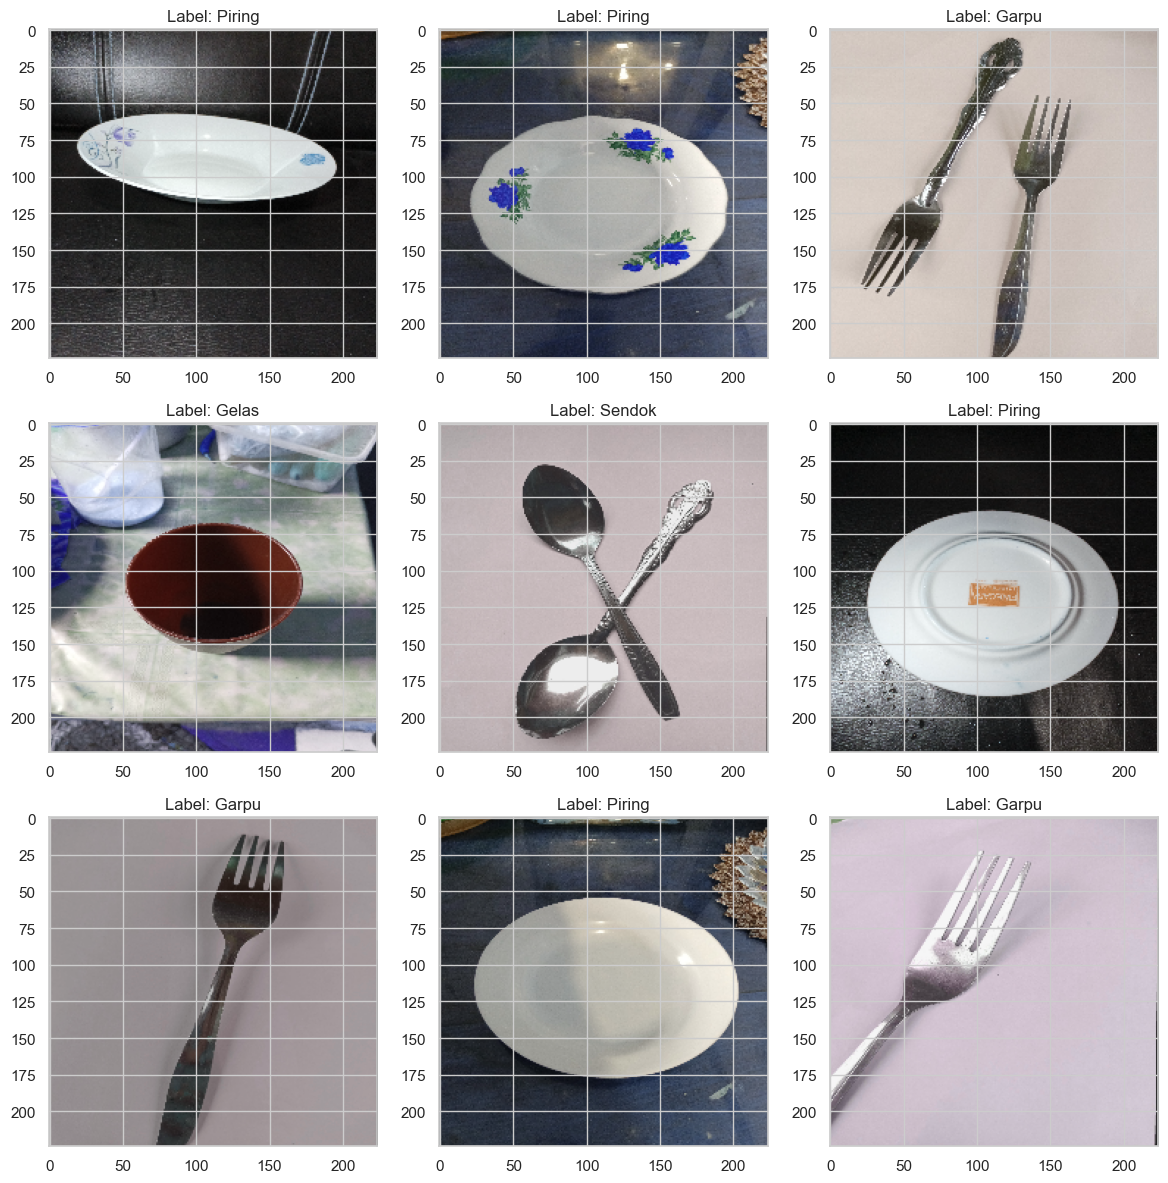

In [8]:
fig, ax = plt.subplots(3, 3) 
fig.set_size_inches(12, 12) 
for i in range(3):
    for j in range(3):  #
        if i * 3 + j < len(X):
            l = rn.randint(0, len(Z))
            ax[i, j].imshow(X[l])
            ax[i, j].set_title('Label: ' + Z[l])
            ax[i, j].axis('on')  
        else:
            ax[i, j].axis('on')  

plt.tight_layout()
plt.show()


### **2.3 ) Label Encoding pada array Y (misalnya galas->0, piring->1, dll.) dan mengonversi ke bentuk one-hot encoding.**

In [9]:
le=LabelEncoder()
Y=le.fit_transform(Z)
Y=to_categorical(Y,4)
X=np.array(X)
X=X/255

### **2.4 ) Membagi dataset menjadi training dan testing set**

In [10]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)


### **2.5 ) Mengatur seed untuk memastikan eksperimen yang dapat direproduksi.**

In [11]:
np.random.seed(42)
rn.seed(42)
tf.random.set_seed(42)

## **3). Modelling**

### **3.1 ) Membangun Model ConvNet**

In [12]:
# Import model Sequential dari Keras
model = Sequential()

# Menambahkan layer konvolusi pertama (Conv2D) dengan 32 filter, ukuran kernel 5x5, padding 'Same', dan aktivasi ReLU
model.add(Conv2D(filters = 32, kernel_size = (5,5), padding = 'Same', activation = 'relu', input_shape = (224,224,3)))

# Menambahkan layer MaxPooling2D untuk mengurangi dimensi hasil konvolusi, pool size 2x2
model.add(MaxPooling2D(pool_size=(2,2)))

# Menambahkan layer konvolusi kedua (Conv2D) dengan 64 filter, ukuran kernel 3x3, padding 'Same', dan aktivasi ReLU
model.add(Conv2D(filters = 64, kernel_size = (3,3), padding = 'Same', activation = 'relu'))

# Menambahkan layer MaxPooling2D dengan pool size 2x2 dan stride 2x2
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

# Menambahkan layer konvolusi ketiga (Conv2D) dengan 96 filter, ukuran kernel 3x3, padding 'Same', dan aktivasi ReLU
model.add(Conv2D(filters = 96, kernel_size = (3,3), padding = 'Same', activation = 'relu'))

# Menambahkan layer MaxPooling2D dengan pool size 2x2 dan stride 2x2
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

# Menambahkan layer konvolusi keempat (Conv2D) dengan 96 filter, ukuran kernel 3x3, padding 'Same', dan aktivasi ReLU
model.add(Conv2D(filters = 96, kernel_size = (3,3), padding = 'Same', activation = 'relu'))

# Menambahkan layer MaxPooling2D dengan pool size 2x2 dan stride 2x2
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

# Mengubah output 2D menjadi vektor 1D dengan menggunakan Flatten agar dapat diterima oleh lapisan Dense
model.add(Flatten())

# Menambahkan lapisan Dense dengan 512 neuron, digunakan untuk menghubungkan fitur yang telah diekstraksi
model.add(Dense(512))

# Menambahkan fungsi aktivasi ReLU pada lapisan Dense
model.add(Activation('relu'))

# Lapisan Dense terakhir dengan 4 neuron untuk klasifikasi dengan aktivasi softmax
model.add(Dense(4, activation = "softmax"))


### **3.2 ) Menggunakan LR Annealer**

In [13]:
# Menentukan batch size untuk pelatihan model (jumlah sampel yang diproses sebelum pembaruan parameter)
batch_size = 128

# Menentukan jumlah epoch (jumlah iterasi melalui seluruh dataset pelatihan)
epochs = 50

# Import callback ReduceLROnPlateau dari Keras untuk mengurangi learning rate saat tidak ada perbaikan dalam akurasi validasi
from keras.callbacks import ReduceLROnPlateau

# Menginisialisasi callback ReduceLROnPlateau
# - monitor: memantau metrik 'val_acc' (akurasi validasi)
# - patience: jika tidak ada peningkatan dalam 3 epoch, learning rate akan dikurangi
# - verbose: memberi output informasi terkait perubahan learning rate
# - factor: mengurangi learning rate sebesar 0.1 jika kondisi 'patience' tercapai
red_lr = ReduceLROnPlateau(monitor='val_acc', patience=3, verbose=1, factor=0.1)


### **3.3 ) Augmentasi Data untuk Mencegah Overfitting**

In [14]:
datagen = ImageDataGenerator(
        featurewise_center=False,  
        samplewise_center=False,  
        featurewise_std_normalization=False,  
        samplewise_std_normalization=False,  
        zca_whitening=False,  
        rotation_range=10,  
        zoom_range = 0.1, 
        width_shift_range=0.2,  
        height_shift_range=0.2, 
        horizontal_flip=True,  
        vertical_flip=False
)  

datagen.fit(x_train)

### **3.4 ) Mengompilasi Model Keras & Summary**

In [15]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 32)      2432      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 56, 56, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 56, 56, 96)        55392     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 28, 28, 96)       0

### **3.5 ) Melakukan Penyesuaian pada Set Pelatihan dan Membuat Prediksi pada Set Validasi**

In [17]:
# Train model
History = model.fit(
    datagen.flow(x_train, y_train, batch_size=batch_size),
    epochs=epochs,
    validation_data=(x_test, y_test),
    verbose=1,
    steps_per_epoch=x_train.shape[0] // batch_size
)

Epoch 1/50
6/6 [==============================] - 25s 829ms/step - loss: 1.4627 - accuracy: 0.3750 - val_loss: 1.1849 - val_accuracy: 0.5450
Epoch 2/50
6/6 [==============================] - 3s 471ms/step - loss: 1.1666 - accuracy: 0.4390 - val_loss: 1.0277 - val_accuracy: 0.5250
Epoch 3/50
6/6 [==============================] - 4s 532ms/step - loss: 0.8780 - accuracy: 0.6161 - val_loss: 1.0571 - val_accuracy: 0.5050
Epoch 4/50
6/6 [==============================] - 3s 616ms/step - loss: 0.7783 - accuracy: 0.6429 - val_loss: 0.7627 - val_accuracy: 0.5950
Epoch 5/50
6/6 [==============================] - 3s 471ms/step - loss: 0.6532 - accuracy: 0.6979 - val_loss: 0.5681 - val_accuracy: 0.7400
Epoch 6/50
6/6 [==============================] - 4s 534ms/step - loss: 0.6081 - accuracy: 0.7515 - val_loss: 0.4838 - val_accuracy: 0.7850
Epoch 7/50
6/6 [==============================] - 4s 570ms/step - loss: 0.5343 - accuracy: 0.7773 - val_loss: 0.3833 - val_accuracy: 0.8950
Epoch 8/50
6/6 [===

## **4). Evaluasi Performa Model**

In [18]:

# Evaluate model
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)  
y_true_classes = np.argmax(y_test, axis=1)

report = classification_report(y_true_classes, y_pred_classes, target_names=le.classes_)
print(report)

7/7 [==============================] - 0s 28ms/step
              precision    recall  f1-score   support

       Garpu       0.98      1.00      0.99        55
       Gelas       1.00      1.00      1.00        49
      Piring       1.00      1.00      1.00        44
      Sendok       1.00      0.98      0.99        52

    accuracy                           0.99       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      0.99      0.99       200



### **PLOT LOSS**

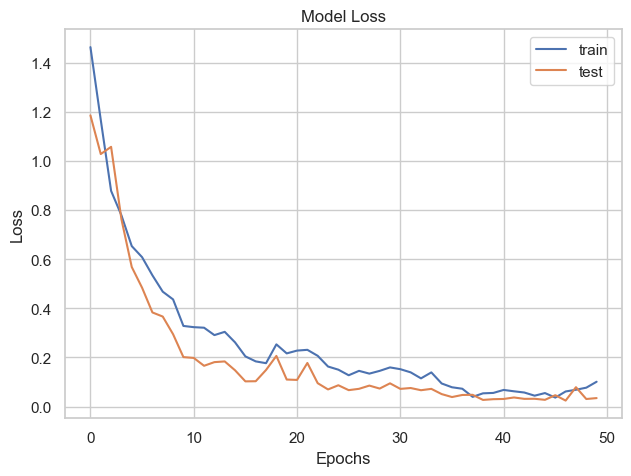

In [19]:
plt.plot(History.history['loss'])
plt.plot(History.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'test'])
plt.show()

### **PLOT AKURASI**

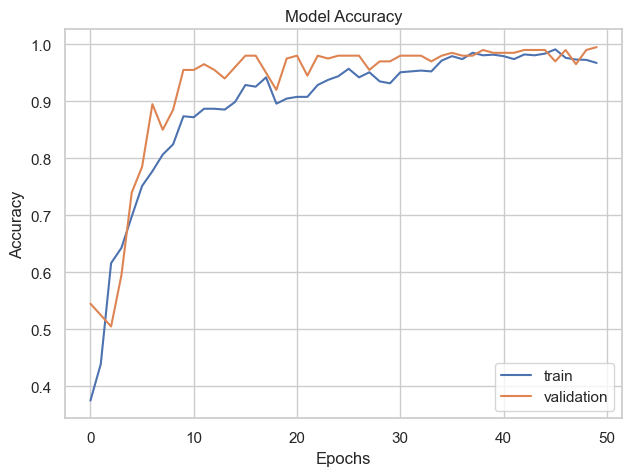

In [20]:
plt.plot(History.history['accuracy'])
plt.plot(History.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()


### **CONFUSION MATRIX**

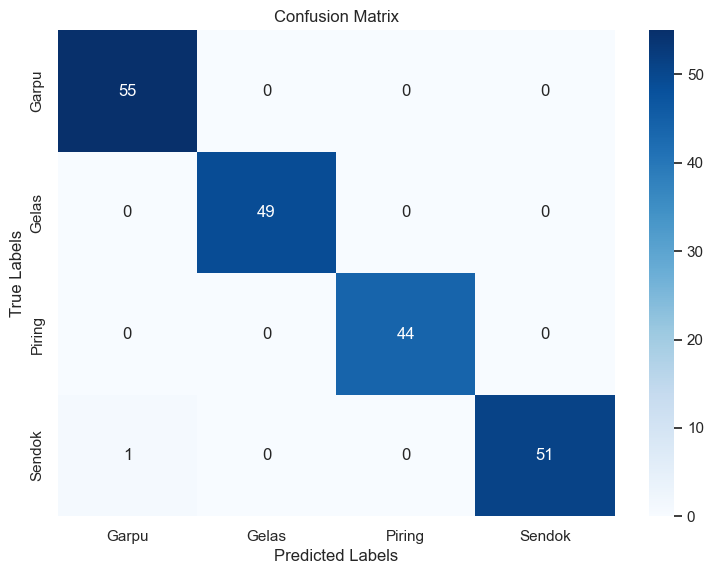

In [21]:
# Compute confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


## **5). Visualisasi Prediksi pada Set Validasi**

In [22]:
# Mendapatkan prediksi pada set validasi
pred=model.predict(x_test)
pred_digits=np.argmax(pred,axis=1)

7/7 [==============================] - 0s 33ms/step


In [23]:
i=0
prop_class=[]
mis_class=[]

for i in range(len(y_test)):
    if(np.argmax(y_test[i])==pred_digits[i]):
        prop_class.append(i)
    if(len(prop_class)==8):
        break

i=0
for i in range(len(y_test)):
    if(not np.argmax(y_test[i])==pred_digits[i]):
        mis_class.append(i)
    if(len(mis_class)==8):
        break

#### **Gambar Yang Terkategori Dengan Benar**

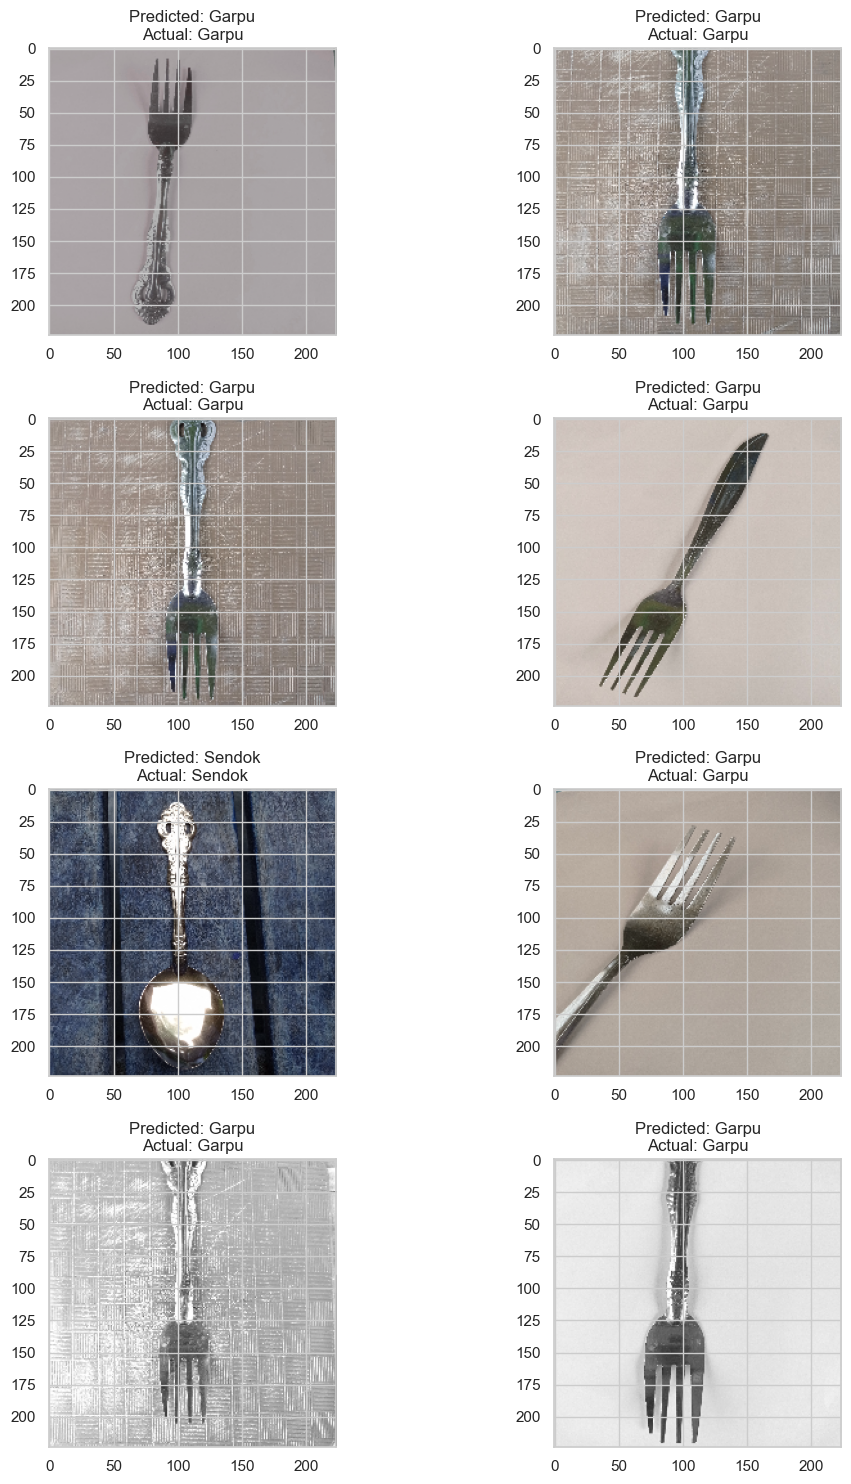

In [25]:
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

count = 0
fig, ax = plt.subplots(4, 2)
fig.set_size_inches(15, 15)

for i in range(4):
    for j in range(2):
        # Tampilkan gambar
        ax[i, j].imshow(x_test[prop_class[count]])
        
        # Dapatkan label prediksi dan label aktual
        predicted_label = le.inverse_transform([pred_digits[prop_class[count]]])[0]
        actual_label = le.inverse_transform([np.argmax(y_test[prop_class[count]])])[0]
        
        # Tetapkan judul untuk subplot
        ax[i, j].set_title(f"Predicted: {predicted_label}\nActual: {actual_label}")
        
        plt.tight_layout()
        count += 1

plt.show()

IndexError: list index out of range

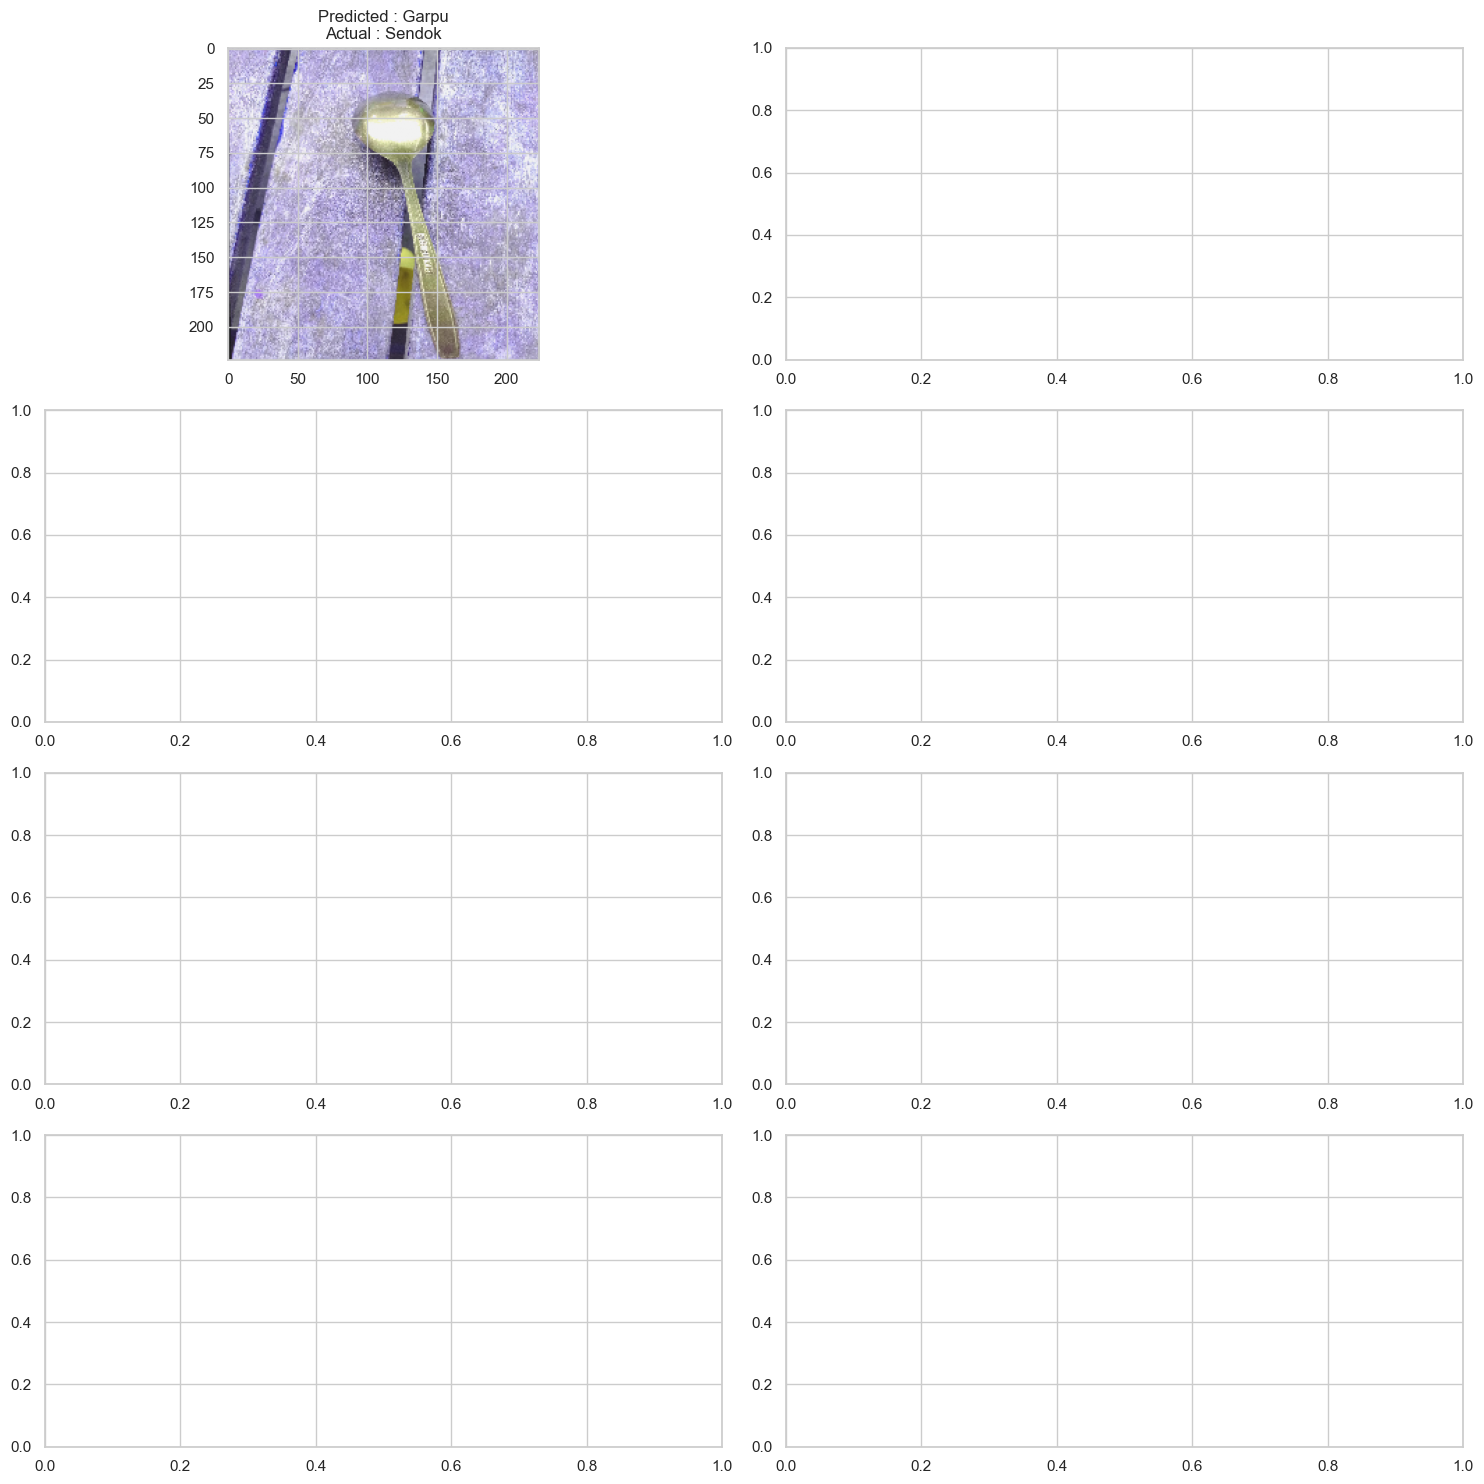

In [26]:
warnings.filterwarnings('ignore')

count = 0
fig, ax = plt.subplots(4, 2)
fig.set_size_inches(15, 15)

for i in range(2):
    for j in range(1):
        # Tampilkan Gambar
        ax[i, j].imshow(x_test[mis_class[count]])
        # Judul dengan Label yang Diprediksi dan Label Aktual
        ax[i, j].set_title(
            f"Predicted : {le.inverse_transform([pred_digits[mis_class[count]]])[0]}\n"
            f"Actual : {le.inverse_transform([np.argmax(y_test[mis_class[count]])])[0]}"
        )
        plt.tight_layout()
        count += 1

plt.show()

In [27]:
from PIL import Image
import matplotlib.pyplot as plt

# Fungsi untuk memproses gambar baru
def process_new_image(image_path, img_size=224):
    # Baca gambar
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)
    # Ubah ukuran gambar
    img = cv2.resize(img, (img_size, img_size))
    # Normalisasi nilai piksel
    img = img / 255.0
    # Ubah menjadi format yang sesuai untuk model
    img = np.expand_dims(img, axis=0)  # Tambahkan dimensi batch
    return img

# Fungsi untuk melakukan prediksi pada gambar baru
def predict_new_image(image_path, model, label_encoder):
    # Proses gambar baru
    processed_img = process_new_image(image_path)
    # Prediksi dengan model
    prediction = model.predict(processed_img)
    # Ambil label kelas dengan probabilitas tertinggi
    predicted_class_index = np.argmax(prediction, axis=1)[0]
    # Konversi indeks kelas menjadi label kelas
    predicted_class_label = label_encoder.inverse_transform([predicted_class_index])[0]
    return predicted_class_label

# Fungsi untuk menampilkan gambar dengan label prediksi
def display_image_with_label(image_path, label):
    # Baca gambar menggunakan PIL
    img = Image.open(image_path)
    # Tampilkan gambar dengan label
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Predicted Label: {label}", fontsize=16, fontweight='bold', color='blue')
    plt.axis('off')  # Hilangkan sumbu
    plt.show()



1/1 [==============================] - 0s 13ms/step


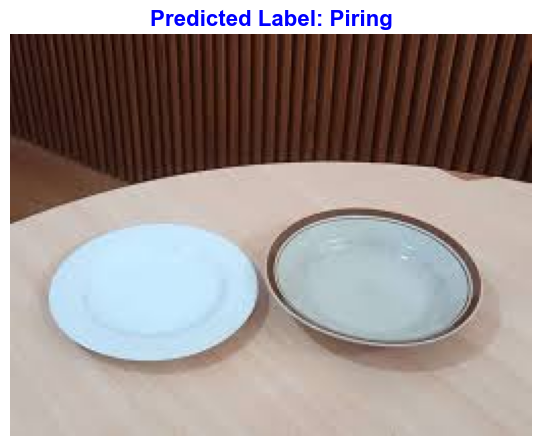

In [38]:
# Path gambar
new_image_path = 'dataset/data uji/5.jpg'

# Lakukan prediksi
predicted_label = predict_new_image(new_image_path, model, le)

# Tampilkan gambar dengan label prediksi
display_image_with_label(new_image_path, predicted_label)